In [1]:
from google.colab import files
uploaded = files.upload()

Saving annual_aqi_by_county_2023.csv to annual_aqi_by_county_2023.csv


In [3]:
import io
df_raw = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))
df_raw.to_csv('annual_aqi_by_county_2023.csv', index=False)

Central Valley Air Quality Analysis, 2023
Loading EPA AQI by County data...
Loaded data for 16 Central Valley counties
     County          Air Basin  Days with AQI  Unhealthy Total  Max AQI
     Colusa  Sacramento Valley            365                0       98
     Fresno San Joaquin Valley            365               58      156
      Glenn  Sacramento Valley            363                0       97
       Kern San Joaquin Valley            365               70      174
      Kings San Joaquin Valley            365               28      148
     Madera San Joaquin Valley            365               15      151
     Merced San Joaquin Valley            365               15      129
 Sacramento  Sacramento Valley            365               12      133
San Joaquin San Joaquin Valley            365                9      119
     Shasta  Sacramento Valley            365                6     1435
     Solano  Sacramento Valley            365                1      105
 Stanislaus San J

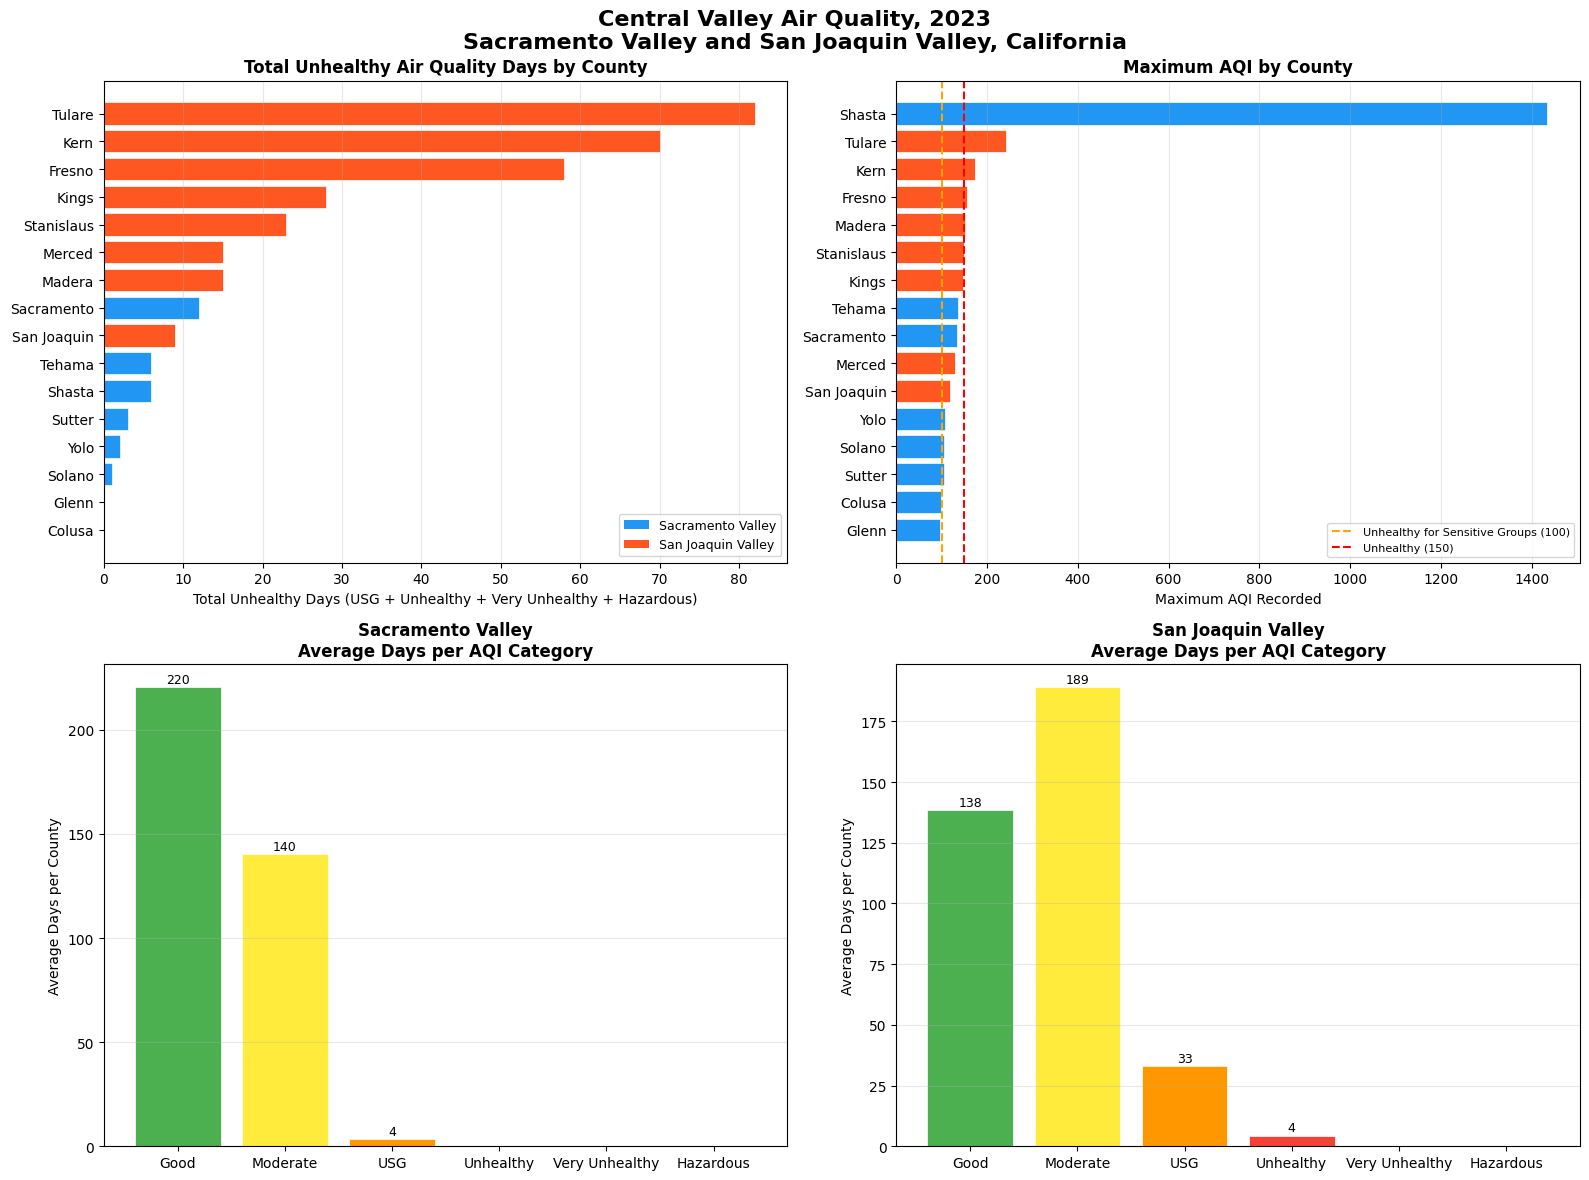


Done. Upload the .py file and chart PNG to your GitHub repo.


In [4]:
"""
Central Valley Air Quality Analysis
Author: Michael Lee
Data Source: EPA Air Quality System (AQS) - AQI by County
https://aqs.epa.gov/aqsweb/airdata/download_files.html

This analysis examines air quality trends across California's Central Valley,
focusing on the Sacramento and San Joaquin Valley air basins. These regions
consistently rank among the worst for air quality in the United States.

Dataset: annual_aqi_by_county_2023.csv
Columns used:
- State, County, Year
- Good Days, Moderate Days, Unhealthy for Sensitive Groups Days
- Unhealthy Days, Very Unhealthy Days, Hazardous Days
- Max AQI, 90th Percentile AQI, Median AQI
- Days with AQI (total monitoring days)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# CONFIGURATION
# ============================================================

CENTRAL_VALLEY_COUNTIES = [
    # Sacramento Valley
    'Sacramento', 'Yolo', 'Solano', 'Sutter', 'Yuba',
    'Colusa', 'Glenn', 'Tehama', 'Shasta',
    # San Joaquin Valley
    'San Joaquin', 'Stanislaus', 'Merced', 'Madera',
    'Fresno', 'Kings', 'Tulare', 'Kern'
]

SACRAMENTO_VALLEY = [
    'Sacramento', 'Yolo', 'Solano', 'Sutter', 'Yuba',
    'Colusa', 'Glenn', 'Tehama', 'Shasta'
]

SAN_JOAQUIN_VALLEY = [
    'San Joaquin', 'Stanislaus', 'Merced', 'Madera',
    'Fresno', 'Kings', 'Tulare', 'Kern'
]

SAC_COLOR = '#2196F3'
SJV_COLOR = '#FF5722'

# ============================================================
# DATA LOADING
# ============================================================

def load_data(filepath):
    """
    Load EPA AQI by County annual summary data.
    Filter to California Central Valley counties.
    """
    print("Loading EPA AQI by County data...")
    df = pd.read_csv(filepath)

    # Filter to California Central Valley
    df = df[
        (df['State'] == 'California') &
        (df['County'].isin(CENTRAL_VALLEY_COUNTIES))
    ].copy()

    # Classify air basin
    df['Air Basin'] = df['County'].apply(
        lambda x: 'Sacramento Valley' if x in SACRAMENTO_VALLEY
        else 'San Joaquin Valley'
    )

    # Calculate unhealthy days total
    df['Unhealthy Total'] = (
        df['Unhealthy for Sensitive Groups Days'] +
        df['Unhealthy Days'] +
        df['Very Unhealthy Days'] +
        df['Hazardous Days']
    )

    # Calculate percent good days
    df['Pct Good'] = (df['Good Days'] / df['Days with AQI'] * 100).round(1)

    print(f"Loaded data for {len(df)} Central Valley counties")
    print(df[['County', 'Air Basin', 'Days with AQI', 'Unhealthy Total', 'Max AQI']].to_string(index=False))
    return df

# ============================================================
# VISUALIZATION
# ============================================================

def create_visualizations(df):
    """
    Four-panel figure summarizing Central Valley air quality in 2023.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        'Central Valley Air Quality, 2023\n'
        'Sacramento Valley and San Joaquin Valley, California',
        fontsize=16, fontweight='bold', y=0.98
    )

    colors_map = {
        c: SAC_COLOR if c in SACRAMENTO_VALLEY else SJV_COLOR
        for c in df['County']
    }

    legend_elements = [
        Patch(facecolor=SAC_COLOR, label='Sacramento Valley'),
        Patch(facecolor=SJV_COLOR, label='San Joaquin Valley')
    ]

    # ---- PANEL 1: Total Unhealthy Days by County ----
    ax1 = axes[0, 0]
    d = df.sort_values('Unhealthy Total', ascending=True)
    colors = [colors_map[c] for c in d['County']]
    ax1.barh(d['County'], d['Unhealthy Total'], color=colors, edgecolor='white', linewidth=0.5)
    ax1.set_xlabel('Total Unhealthy Days (USG + Unhealthy + Very Unhealthy + Hazardous)', fontsize=10)
    ax1.set_title('Total Unhealthy Air Quality Days by County', fontsize=12, fontweight='bold')
    ax1.legend(handles=legend_elements, fontsize=9, loc='lower right')
    ax1.grid(axis='x', alpha=0.3)

    # ---- PANEL 2: Max AQI by County ----
    ax2 = axes[0, 1]
    d2 = df.sort_values('Max AQI', ascending=True)
    colors2 = [colors_map[c] for c in d2['County']]
    ax2.barh(d2['County'], d2['Max AQI'], color=colors2, edgecolor='white', linewidth=0.5)
    ax2.axvline(x=100, color='orange', linestyle='--', linewidth=1.5, label='Unhealthy for Sensitive Groups (100)')
    ax2.axvline(x=150, color='red', linestyle='--', linewidth=1.5, label='Unhealthy (150)')
    ax2.set_xlabel('Maximum AQI Recorded', fontsize=10)
    ax2.set_title('Maximum AQI by County', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(axis='x', alpha=0.3)

    # ---- PANEL 3: AQI Category Breakdown - Sacramento Valley ----
    ax3 = axes[1, 0]
    sac = df[df['Air Basin'] == 'Sacramento Valley'].copy()
    categories = ['Good Days', 'Moderate Days',
                  'Unhealthy for Sensitive Groups Days',
                  'Unhealthy Days', 'Very Unhealthy Days', 'Hazardous Days']
    cat_labels = ['Good', 'Moderate', 'USG', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
    cat_colors = ['#4CAF50', '#FFEB3B', '#FF9800', '#F44336', '#9C27B0', '#795548']

    sac_means = [sac[c].mean() for c in categories]
    bars = ax3.bar(cat_labels, sac_means, color=cat_colors, edgecolor='white', linewidth=0.5)
    ax3.set_ylabel('Average Days per County', fontsize=10)
    ax3.set_title('Sacramento Valley\nAverage Days per AQI Category', fontsize=12, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, sac_means):
        if val > 1:
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    # ---- PANEL 4: AQI Category Breakdown - San Joaquin Valley ----
    ax4 = axes[1, 1]
    sjv = df[df['Air Basin'] == 'San Joaquin Valley'].copy()
    sjv_means = [sjv[c].mean() for c in categories]
    bars2 = ax4.bar(cat_labels, sjv_means, color=cat_colors, edgecolor='white', linewidth=0.5)
    ax4.set_ylabel('Average Days per County', fontsize=10)
    ax4.set_title('San Joaquin Valley\nAverage Days per AQI Category', fontsize=12, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars2, sjv_means):
        if val > 1:
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig('central_valley_air_quality_2023.png', dpi=150, bbox_inches='tight')
    print("\nFigure saved as central_valley_air_quality_2023.png")
    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():
    print("=" * 60)
    print("Central Valley Air Quality Analysis, 2023")
    print("=" * 60)

    # Load data
    # File: annual_aqi_by_county_2023.csv
    # Download from: https://aqs.epa.gov/aqsweb/airdata/download_files.html
    df = load_data('annual_aqi_by_county_2023.csv')

    # Key findings
    print("\n--- Key Findings ---")
    worst_unhealthy = df.nlargest(1, 'Unhealthy Total').iloc[0]
    print(f"Most unhealthy days: {worst_unhealthy['County']} ({worst_unhealthy['Unhealthy Total']:.0f} days)")

    highest_max = df.nlargest(1, 'Max AQI').iloc[0]
    print(f"Highest max AQI: {highest_max['County']} (AQI {highest_max['Max AQI']})")

    # Air basin comparison
    print("\n--- Air Basin Comparison ---")
    basin = df.groupby('Air Basin').agg(
        Avg_Unhealthy_Days=('Unhealthy Total', 'mean'),
        Avg_Max_AQI=('Max AQI', 'mean'),
        Avg_Good_Days=('Good Days', 'mean')
    ).round(1)
    print(basin)

    # Generate chart
    print("\nGenerating visualizations...")
    create_visualizations(df)
    print("\nDone. Upload the .py file and chart PNG to your GitHub repo.")


if __name__ == '__main__':
    main()
